In [ ]:
!pip install torch-scatter -f https://data.pyg.org/whl/torch-2.11.0+cu128.html
!pip install torch-sparse -f https://data.pyg.org/whl/torch-2.11.0+cu128.html
!pip install torch-cluster -f https://data.pyg.org/whl/torch-2.11.0+cu128.html
!pip install torch-geometric

Looking in links: https://data.pyg.org/whl/torch-2.11.0+cu128.html
Looking in links: https://data.pyg.org/whl/torch-2.11.0+cu128.html
Looking in links: https://data.pyg.org/whl/torch-2.11.0+cu128.html


In [ ]:
import torch_geometric
print("PyG installed successfully")

PyG installed successfully


In [ ]:
import pandas as pd
import torch
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
import torch.nn.functional as F

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
features = pd.read_csv("/content/drive/MyDrive/elliptic_txs_features.csv", header=None)

In [ ]:
classes=pd.read_csv("/content/drive/MyDrive/elliptic_txs_classes.csv")

In [ ]:
edge_lists=pd.read_csv("/content/drive/MyDrive/elliptic_txs_edgelist.csv")

In [ ]:
print(features.shape)
print(edge_lists.shape)
print(classes.shape)

(203769, 167)
(234355, 2)
(203769, 2)


In [ ]:
tx_ids = features.iloc[:,0]

x = features.iloc[:,1:]

In [ ]:

x = torch.tensor(
    x.values,
    dtype=torch.float
)

In [ ]:
print(x.shape)

torch.Size([203769, 166])


In [ ]:
node_mapping = {
    tx_id:i
    for i,tx_id in enumerate(tx_ids)
}

In [ ]:
edge_lists.head()

,txId1,txId2
0,230425980,5530458
1,232022460,232438397
2,230460314,230459870
3,230333930,230595899
4,232013274,232029206


In [ ]:
edge_lists.columns = [
    "source",
    "target"
]

In [ ]:
edge_lists["source"] = edge_lists["source"].map(node_mapping)

edge_lists["target"] = edge_lists["target"].map(node_mapping)

In [ ]:
edge_lists = edge_lists.dropna()


In [ ]:
edge_index = torch.tensor(
    edge_lists.values.T,
    dtype=torch.long
)
print(edge_index.shape)

torch.Size([2, 234355])


In [ ]:
print(edge_index.max())
print(x.shape[0])

tensor(203768)
203769


In [ ]:
classes.head()

,txId,class
0,230425980,unknown
1,5530458,unknown
2,232022460,unknown
3,232438397,2
4,230460314,unknown


In [ ]:
label_mapping = dict(
    zip(
        classes.iloc[:,0],
        classes.iloc[:,1]
    )
)

In [ ]:
y=[]

for tx in tx_ids:

    label = label_mapping[tx]

    if label=="1":
        y.append(0)       # illicit

    elif label=="2":
        y.append(1)       # licit

    else:
        y.append(-1)      # unknown

In [ ]:
y=torch.tensor(
    y,
    dtype=torch.long
)
print(torch.unique(y))

tensor([-1,  0,  1])


In [ ]:
data = Data(
    x=x,
    edge_index=edge_index,
    y=y
)
print(data)

Data(x=[203769, 166], edge_index=[2, 234355], y=[203769])


In [ ]:
device=torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

data=data.to(device)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.nn import BatchNorm1d
from torch_geometric.nn import GATConv


class GAT(nn.Module):

    def __init__(
        self,
        in_channels,
        hidden_channels,
        out_channels,
    ):
        super().__init__()

        self.conv1 = GATConv(
            in_channels,
            hidden_channels,
            heads=4
        )

        self.bn1 = BatchNorm1d(
            hidden_channels * 4
        )

        self.conv2 = GATConv(
            hidden_channels * 4,
            out_channels,
            heads=1
        )


    def forward(self, x, edge_index, return_attention=False):

        if return_attention:

            # First GAT layer + attention
            x, (edge_index1, att1) = self.conv1(
                x,
                edge_index,
                return_attention_weights=True
            )

            x = self.bn1(x)

            x = F.relu(x)

            x = F.dropout(
                x,
                p=0.3,
                training=self.training
            )


            # Second GAT layer + attention
            x, (edge_index2, att2) = self.conv2(
                x,
                edge_index,
                return_attention_weights=True
            )

            return x, edge_index1, att1, edge_index2, att2


        else:

            # Normal training/inference output
            x = self.conv1(
                x,
                edge_index
            )

            x = self.bn1(x)

            x = F.relu(x)

            x = F.dropout(
                x,
                p=0.3,
                training=self.training
            )

            x = self.conv2(
                x,
                edge_index
            )

            return x

In [ ]:
torch.unique(data.y)

tensor([-1,  0,  1], device='cuda:0')

In [ ]:
model=GAT(
    in_channels=data.num_features,
    hidden_channels=128,
    out_channels=2
).to(device)

In [ ]:
torch.cuda.empty_cache()

In [ ]:
labeled_nodes = data.y != -1

In [ ]:
from sklearn.model_selection import train_test_split


indices = torch.where(labeled_nodes)[0].cpu().numpy()


# First split: 80% train+validation, 20% test
train_val_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42
)


# Second split: split train+validation into train and validation
train_idx, val_idx = train_test_split(
    train_val_idx,
    test_size=0.125,   # 10% of total data
    random_state=42
)

In [ ]:
data.train_mask = torch.zeros(
    data.num_nodes,
    dtype=torch.bool
)

data.val_mask = torch.zeros(
    data.num_nodes,
    dtype=torch.bool
)

data.test_mask = torch.zeros(
    data.num_nodes,
    dtype=torch.bool
)


data.train_mask[train_idx] = True

data.val_mask[val_idx] = True

data.test_mask[test_idx] = True

In [ ]:
import torch.nn.functional as F

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.005,
    weight_decay=5e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5,
    min_lr=1e-5
)
class_counts = torch.bincount(
    data.y[data.train_mask]
)

criterion = torch.nn.CrossEntropyLoss()

In [ ]:

best_val_loss = float("inf")

patience = 10

counter = 0


for epoch in range(200):

    # -------- TRAIN --------

    model.train()

    optimizer.zero_grad()


    out = model(
        data.x,
        data.edge_index
    )


    train_loss = criterion(
        out[data.train_mask],
        data.y[data.train_mask]
    )


    train_loss.backward()

    optimizer.step()



    # -------- VALIDATION --------

    model.eval()

    with torch.no_grad():

        out = model(
            data.x,
            data.edge_index
        )


        val_loss = criterion(
            out[data.val_mask],
            data.y[data.val_mask]
        )



    print(
        f"Epoch {epoch+1}, "
        f"Train Loss: {train_loss.item():.4f}, "
        f"Val Loss: {val_loss.item():.4f} "
        f"LR: {optimizer.param_groups[0]['lr']:.6f}"
    )


    # -------- EARLY STOPPING --------

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        counter = 0


        torch.save(
            model.state_dict(),
            "best_gat_model.pth"
        )


    else:

        counter += 1

    scheduler.step(val_loss)



    if counter >= patience:

        print("Early stopping triggered")

        break

Epoch 1, Train Loss: 0.4175, Val Loss: 0.3663 LR: 0.005000
Epoch 2, Train Loss: 0.2581, Val Loss: 0.3049 LR: 0.005000
Epoch 3, Train Loss: 0.2643, Val Loss: 0.3333 LR: 0.005000
Epoch 4, Train Loss: 0.2494, Val Loss: 0.3452 LR: 0.005000
Epoch 5, Train Loss: 0.2340, Val Loss: 0.3178 LR: 0.005000
Epoch 6, Train Loss: 0.2190, Val Loss: 0.2801 LR: 0.005000
Epoch 7, Train Loss: 0.2067, Val Loss: 0.2508 LR: 0.005000
Epoch 8, Train Loss: 0.2003, Val Loss: 0.2317 LR: 0.005000
Epoch 9, Train Loss: 0.1909, Val Loss: 0.2196 LR: 0.005000
Epoch 10, Train Loss: 0.1836, Val Loss: 0.2083 LR: 0.005000
Epoch 11, Train Loss: 0.1776, Val Loss: 0.1939 LR: 0.005000
Epoch 12, Train Loss: 0.1725, Val Loss: 0.1817 LR: 0.005000
Epoch 13, Train Loss: 0.1697, Val Loss: 0.1736 LR: 0.005000
Epoch 14, Train Loss: 0.1647, Val Loss: 0.1687 LR: 0.005000
Epoch 15, Train Loss: 0.1614, Val Loss: 0.1642 LR: 0.005000
Epoch 16, Train Loss: 0.1567, Val Loss: 0.1601 LR: 0.005000
Epoch 17, Train Loss: 0.1521, Val Loss: 0.1569 LR

In [ ]:
model.load_state_dict(
    torch.load("best_gat_model.pth")
)

<All keys matched successfully>

In [ ]:
model.eval()

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

with torch.no_grad():

    out = model(
        data.x,
        data.edge_index
    )

    # Convert logits to probabilities
    probabilities = torch.softmax(out, dim=1)

    # Fraud probability (class 0)
    fraud_probability = probabilities[:,0]

# Change threshold here
threshold = 0.35

# Predict using threshold
predictions = torch.where(
    fraud_probability >= threshold,0,1)

y_true = data.y[data.test_mask].cpu().numpy()

y_pred = predictions[data.test_mask].cpu().numpy()

y_prob= fraud_probability[data.test_mask].cpu().numpy()

print("Classification Report")
print(
    classification_report(y_true,y_pred)
)

print("Confusion Matrix")
print(
    confusion_matrix(
        y_true,
        y_pred ))

print("ROC-AUC")
print(
    roc_auc_score(y_true == 0,y_prob))

Classification Report
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       899
           1       0.99      0.98      0.98      8414

    accuracy                           0.97      9313
   macro avg       0.91      0.93      0.92      9313
weighted avg       0.97      0.97      0.97      9313

Confusion Matrix
[[ 791  108]
 [ 150 8264]]
ROC-AUC
0.9824431868809148


In [ ]:
with torch.no_grad():

    out, edge_index1, att1, edge_index2, att2 = model(
        data.x,
        data.edge_index,
        return_attention=True
    )

In [ ]:
from torch_geometric.explain import Explainer
from torch_geometric.explain.algorithm import GNNExplainer

# Create explainer
explainer = Explainer(
    model=model,
    algorithm=GNNExplainer(epochs=200),
    explanation_type="model",
    node_mask_type="attributes",
    edge_mask_type="object",
    model_config=dict(
        mode="multiclass_classification",
        task_level="node",
        return_type="raw"
    )
)




In [ ]:
def explain_transaction(node_id):

    model.eval()

    # ---------------------------
    # 1. Prediction
    # ---------------------------
    with torch.no_grad():

        out = model(
            data.x,
            data.edge_index
        )

    probabilities = torch.softmax(
        out,
        dim=1
    )

    prediction = out[node_id].argmax().item()

    confidence = probabilities[node_id][prediction].item()


    # ---------------------------
    # 2. GAT Attention Explanation
    # ---------------------------
    with torch.no_grad():

        out, edge_index1, att1, edge_index2, att2 = model(
            data.x,
            data.edge_index,
            return_attention=True
        )


    # Use second GAT layer attention
    edge_index = edge_index2
    attention_weights = att2.squeeze()


    # Find edges connected to selected node
    mask = (
        (edge_index[0] == node_id) |
        (edge_index[1] == node_id)
    )


    connected_edges = edge_index[:, mask]
    connected_attention = attention_weights[mask]


    neighbors = []


    for i in range(connected_edges.shape[1]):

        source = connected_edges[0, i].item()
        target = connected_edges[1, i].item()

        weight = connected_attention[i].item()


        if source == node_id:
            neighbor = target
        else:
            neighbor = source


        neighbors.append(
            (neighbor, weight)
        )


    neighbors = sorted(
        neighbors,
        key=lambda x:x[1],
        reverse=True
    )


    top_neighbors = neighbors[:5]


    # ---------------------------
    # 3. Feature Importance
    # ---------------------------

    explanation = explainer(
        data.x,
        data.edge_index,
        index=node_id
    )


    feature_importance = explanation.node_mask[node_id]


    top_values, top_indices = torch.topk(
        feature_importance,
        k=10
    )


    important_features = []


    for feature, score in zip(
        top_indices,
        top_values
    ):

        important_features.append(
            (
                feature.item(),
                score.item()
            )
        )


    # ---------------------------
    # Return everything
    # ---------------------------

    return {
        "node_id": node_id,
        "prediction": prediction,
        "confidence": confidence,
        "neighbors": top_neighbors,
        "features": important_features
    }

In [ ]:
node_id= int(input("Enter the node : "))
result = explain_transaction(1234)

print(result)

Enter the node : 1234
{'node_id': 1234, 'prediction': 1, 'confidence': 0.7815970182418823, 'neighbors': [(1234, 0.5589771270751953), (3200, 0.4410229027271271), (1081, 0.415354460477829)], 'features': [(91, 0.6090855002403259), (63, 0.5314780473709106), (164, 0.5182523131370544), (62, 0.5126914978027344), (139, 0.49337345361709595), (89, 0.4826520085334778), (115, 0.48136499524116516), (92, 0.4666318893432617), (86, 0.4604588449001312), (136, 0.4335049092769623)]}


In [ ]:
torch.save(
    model.state_dict(),
    "/content/drive/MyDrive/best_gat_model.pth"
)

print("Model saved successfully")


Model saved successfully


In [ ]:
torch.save(
    data,
    "/content/drive/MyDrive/elliptic_data.pt"
)
print("Data saved successfully")

Data saved successfully


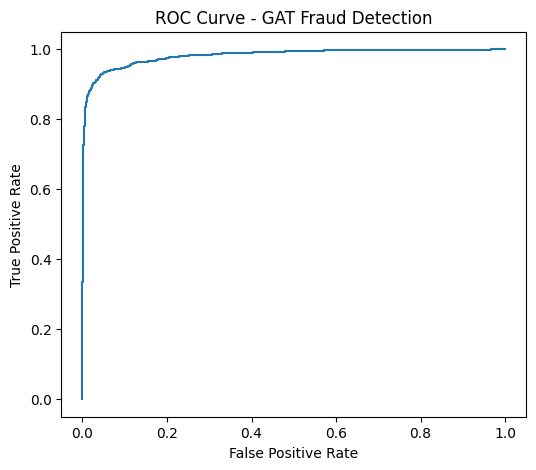

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt


fpr, tpr, thresholds = roc_curve(
    y_true == 0,
    y_prob
)


plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve - GAT Fraud Detection"
)

plt.show()

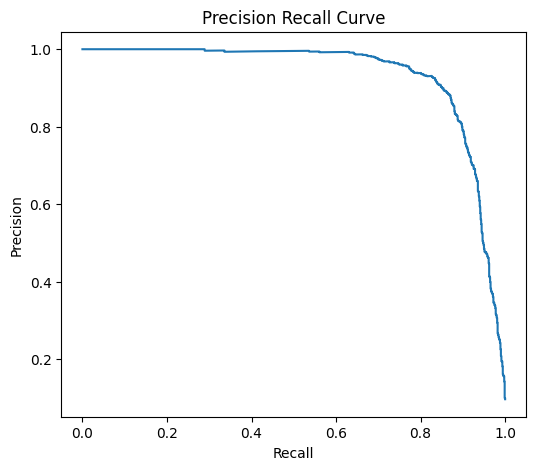

In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt


precision, recall, thresholds = precision_recall_curve(
    y_true == 0,
    y_prob
)


plt.figure(figsize=(6,5))

plt.plot(
    recall,
    precision
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Precision Recall Curve"
)

plt.show()

In [ ]:
model.eval()

with torch.no_grad():

    out = model(
        data.x,
        data.edge_index
    )


predictions = out.argmax(dim=1)


fraud_nodes = torch.where(
    predictions == 1
)[0]


print("Fraud transactions:", len(fraud_nodes))

Fraud transactions: 188741


In [ ]:
import os

print(
    os.path.exists("/content/drive/MyDrive/best_gat_model.pth")
)

print(
    os.path.exists("/content/drive/MyDrive/elliptic_data.pt")
)

True
True
